This script takes the all the images, data and background saved in the previosu script saves a subset of that data



## User Input
Choose which dataset to work on

In [ ]:
%run -i ../src/General_Data/Analysis/Data_Classes.py
pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = January_2024_571.return_params()
pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = January_2024_241.return_params()

pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = March_2024_571.return_params()
pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = March_2024_241.return_params()

pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = April_2024_571.return_params()
pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = April_2024_241.return_params()

# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = June_2024_571.return_params()

pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = October_2024_571.return_params()

pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = January_2025_241.return_params()
pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = January_2025_571.return_params()

# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = test_571_smoke.return_params()
# # pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = test_241.return_params()


## Import Statements

In [172]:
import numpy as np
import pandas as pd
import os
import glob
import copy
from Image_Analysis import *
from scipy.ndimage import median_filter


## Manipulate Inputs

In [173]:
screen_nickname = screen.split(':')[2]
os.makedirs(save_loc, exist_ok=True)

## Load Data

In [174]:
all_images = np.load(save_loc + 'total_images_stack_' + screen_nickname + '.npy')

all_data = pd.read_pickle(save_loc + 'total_data_stack_' + screen_nickname + '.pkl')

bg = np.load(save_loc + 'background_' + screen_nickname + '.npy')


In [175]:
# for i in range(len(all_images)):
#     plt.figure()
#     plt.imshow(all_images[i,:,:])
#     plt.title(str(i))

### USER INPUT: threshold to remove clipped images

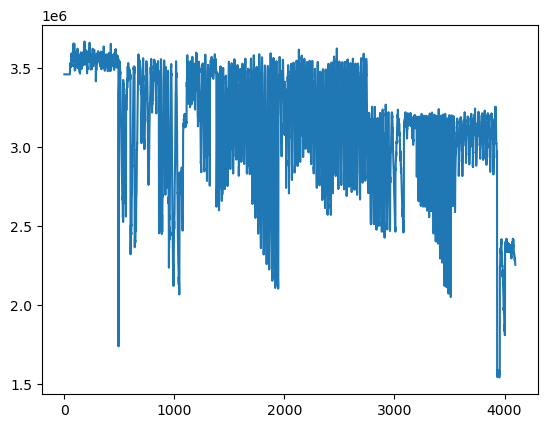

In [176]:
sums = []
for i in range(np.shape(all_images)[0]):
    sums.append(np.sum(all_images[i,:,:]))
plt.plot(sums)

In [177]:
thresh = 2.6e6

In [178]:
rmidx = np.array(sums)<thresh
all_images = all_images[~rmidx,:,:]



In [179]:
all_data.reset_index(drop=True,inplace=True)
all_data = all_data[~rmidx]
all_data.reset_index(drop=True,inplace=True)


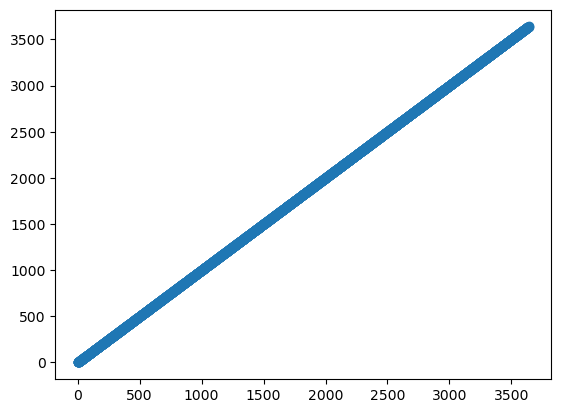

In [180]:

plt.scatter(range(len(all_data)),all_data.index)

In [181]:
all_img_list_bg_subt = [median_filter(all_images[i,:,:]-bg,size=3) for i in range(len(all_images))]
all_img_list = [all_images[i,:,:] for i in range(len(all_images))]


In [182]:
# for img in all_img_list:
#     plt.figure()
#     plt.imshow(img)

#### Filter clipped images

In [183]:
def get_border_mean(img,border_width=10):
    top = img[:border_width, :]
    bottom = img[-border_width:, :]
    left = img[border_width:-border_width, :border_width]
    right = img[border_width:-border_width, -border_width:]
    bg = np.concatenate([
        np.reshape(top,-1),
        np.reshape(bottom,-1),
        np.reshape(left,-1),
        np.reshape(right,-1)
    ],axis=0)
    return np.mean(bg)

def get_proj_mean(proj,border_width=10):
    top = proj[:border_width]
    bottom = proj[-border_width:]
    
    bg = np.concatenate([
        np.reshape(top,-1),
        np.reshape(bottom,-1),
    ],axis=0)
    return np.mean(bg)

def get_x_y_proj_mean(img):
    xproj = np.sum(img,axis=0)
    yproj = np.sum(img,axis=1)
    xmean = get_proj_mean(xproj)
    ymean = get_proj_mean(yproj)
    return xmean,ymean

In [184]:
arrs = [get_border_mean(i) for i in all_img_list_bg_subt]

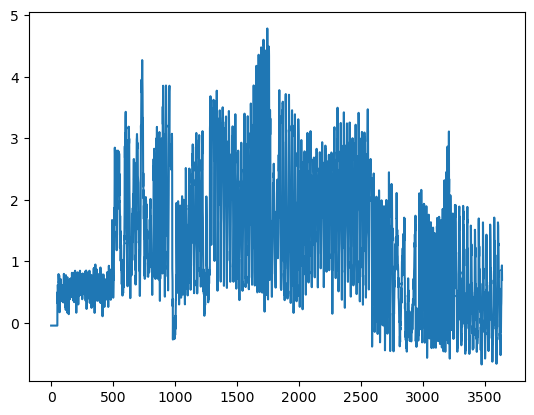

In [185]:
plt.plot(arrs)

## User Input: bg threshold to cut clipped images

In [186]:
bg_thresh = 9

In [187]:
good_idx = np.array(arrs)<bg_thresh
good_imgs = np.array(all_img_list_bg_subt)[good_idx,:,:]
good_img_list = np.array(all_img_list)[good_idx,:,:]

good_data = all_data.loc[good_idx]

In [188]:
np.sum(good_idx)

np.int64(3641)

### Get clipped projections that slip through

In [189]:
xmeans = [get_x_y_proj_mean(good_imgs[i,:,:])[0] for i in np.arange(np.shape(good_imgs)[0])]
ymeans = [get_x_y_proj_mean(good_imgs[i,:,:])[1] for i in np.arange(np.shape(good_imgs)[0])]

## User Input: bg threshold to cut projections

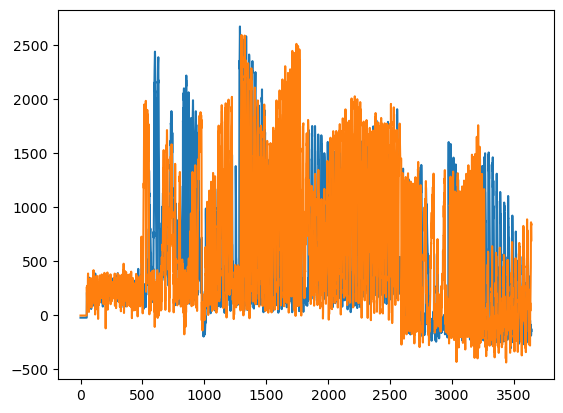

In [190]:
plt.plot(xmeans,label='xmeans')
plt.plot(ymeans,label='ymeans')

In [191]:
proj_thresh = 4000

In [165]:
good_good_idx = (np.array(xmeans)>proj_thresh) | (np.array(ymeans)>proj_thresh)
good_good_idx = ~good_good_idx

In [166]:
selected_imgs = good_imgs[good_good_idx]
selected_img_list = good_img_list[good_good_idx,:,:]
selected_data = good_data.loc[good_good_idx].reset_index(drop=True)

In [167]:
print(len(selected_data))
print(len(selected_imgs))

66
66


In [168]:
print(sum(good_good_idx))

66


In [169]:
# selected_img_list = np.array(selected_img_list)

In [170]:
np.save(save_loc + 'all_images_stack_' + screen_nickname + '.npy',selected_img_list)

selected_data.to_pickle(save_loc + 'all_data_stack_' + screen_nickname + '.pkl')


In [88]:
# np.save(save_loc + 'background_' + screen_nickname + '.npy',rot_bg_cropp)